In [1]:
# ═══════════════════════════════════════════════════
# CELL 1 — Setup (with explicit MLflow URI)
# ═══════════════════════════════════════════════════
import sys
import os
import warnings

# Allow imports from project root (src/)
sys.path.append('..')

# Set CWD to project root
os.chdir("..")
print("CWD:", os.getcwd())

import mlflow

# EXPLICITLY set tracking URI to a writable folder in your project
mlflow.set_tracking_uri("file:///Users/apple/NetSentinel/mlruns")
print("Tracking URI:", mlflow.get_tracking_uri())

import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

print("✅ Setup complete")

CWD: /Users/apple/NetSentinel


/Users/apple/NetSentinel/venv_tf/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


Tracking URI: file:///Users/apple/NetSentinel/mlruns
✅ Setup complete


In [2]:
import mlflow

print("Experiment before:", mlflow.get_experiment_by_name("netsentinel_test"))

mlflow.set_experiment("netsentinel_test")

with mlflow.start_run(run_name="sanity_run"):
    mlflow.log_param("learning_rate", 0.01)
    mlflow.log_metric("f1", 0.42)

print("Done logging.")

Experiment before: <Experiment: artifact_location='file:///Users/apple/NetSentinel/mlruns/135363828713954824', creation_time=1772596001904, experiment_id='135363828713954824', last_update_time=1772596001904, lifecycle_stage='active', name='netsentinel_test', tags={}>
Done logging.


In [3]:
# ═══════════════════════════════════════════════════
# CELL 2 — Load ML-Ready Data
# ═══════════════════════════════════════════════════
DATA_PATH = "data/processed/"

X_train = pd.read_csv(f"{DATA_PATH}X_train.csv")
X_test = pd.read_csv(f"{DATA_PATH}X_test.csv")
y_train = pd.read_csv(f"{DATA_PATH}y_train.csv").values.ravel()
y_test = pd.read_csv(f"{DATA_PATH}y_test.csv").values.ravel()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape} (Attack: {y_train.sum():,})")
print(f"y_test:  {y_test.shape}  (Attack: {y_test.sum():,})")
print("\n✅ Data loaded")

X_train: (3352090, 48)
X_test:  (504160, 48)
y_train: (3352090,) (Attack: 1,676,045)
y_test:  (504160,)  (Attack: 85,148)

✅ Data loaded


In [4]:
# ═══════════════════════════════════════════════════
# CELL 3 — Train Isolation Forest
# ═══════════════════════════════════════════════════
from src.models.isolation_forest import IsolationForestDetector

iso_forest = IsolationForestDetector(
    contamination=0.1,
    n_estimators=200
)

iso_forest.train(X_train)
iso_results = iso_forest.evaluate(X_test, y_test)


TRAINING: Isolation Forest
  Contamination: 0.1
  Estimators:    200
  Samples:       3,352,090
  Features:      48
  ✅ Training complete (23.50s)

EVALUATING: Isolation Forest

  Metric                    Score
  ──────────────────────────────
  accuracy                 0.7558
  precision                0.1450
  recall                   0.0910
  f1                       0.1119
  roc_auc                  0.5284
  training_time             23.50s

  Classification Report:
              precision    recall  f1-score   support

      Benign     0.8283    0.8909    0.8584    419012
      Attack     0.1450    0.0910    0.1119     85148

    accuracy                         0.7558    504160
   macro avg     0.4866    0.4910    0.4852    504160
weighted avg     0.7129    0.7558    0.7324    504160



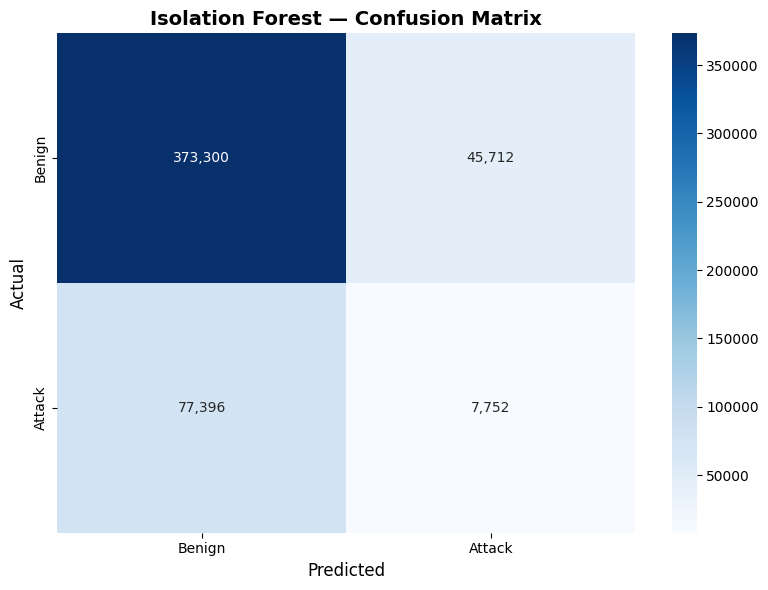


  Interpretation:
    True Negatives  (correctly benign):  373,300
    True Positives  (correctly attack):  7,752
    False Positives (false alarms):      45,712
    False Negatives (missed attacks):    77,396

    False Alarm Rate: 10.91%
    Miss Rate:        90.90%


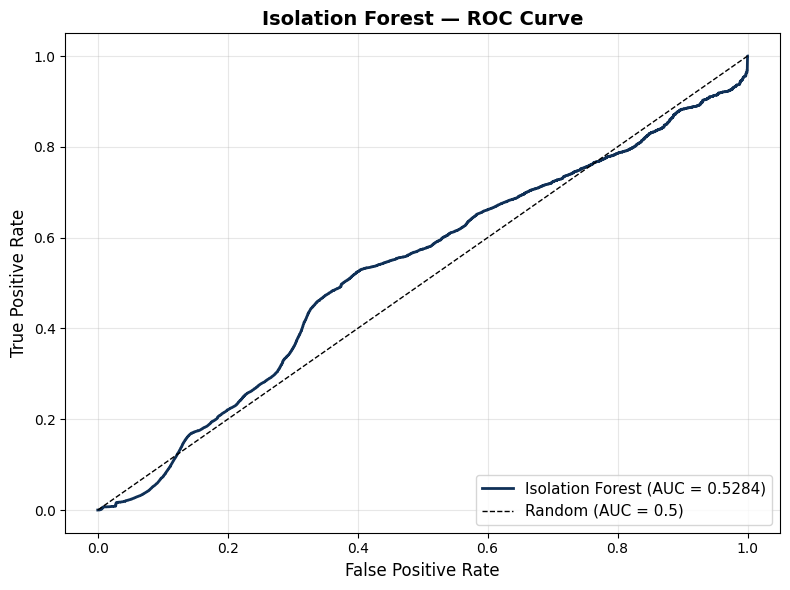

In [5]:
# ═══════════════════════════════════════════════════
# CELL 4 — Isolation Forest Visualizations
# ═══════════════════════════════════════════════════
iso_forest.plot_confusion_matrix(X_test, y_test,
    save_path="notebooks/iso_forest_cm.png")

iso_forest.plot_roc_curve(X_test, y_test,
    save_path="notebooks/iso_forest_roc.png")

In [6]:
# ═══════════════════════════════════════════════════
# CELL 5 — Train Random Forest
# ═══════════════════════════════════════════════════
from src.models.random_forest import RandomForestDetector

rf = RandomForestDetector(
    n_estimators=200,
    max_depth=20
)

rf.train(X_train, y_train)
rf_results = rf.evaluate(X_test, y_test)


TRAINING: Random Forest
  Estimators:       200
  Max depth:        20
  Training samples: 3,352,090
  Features:         48
  ✅ Training complete (342.12s)

EVALUATING: Random Forest

  Metric                    Score
  ──────────────────────────────
  accuracy                 0.9989
  precision                0.9942
  recall                   0.9992
  f1                       0.9967
  roc_auc                  1.0000
  training_time            342.12s

  Classification Report:
              precision    recall  f1-score   support

      Benign     0.9998    0.9988    0.9993    419012
      Attack     0.9942    0.9992    0.9967     85148

    accuracy                         0.9989    504160
   macro avg     0.9970    0.9990    0.9980    504160
weighted avg     0.9989    0.9989    0.9989    504160



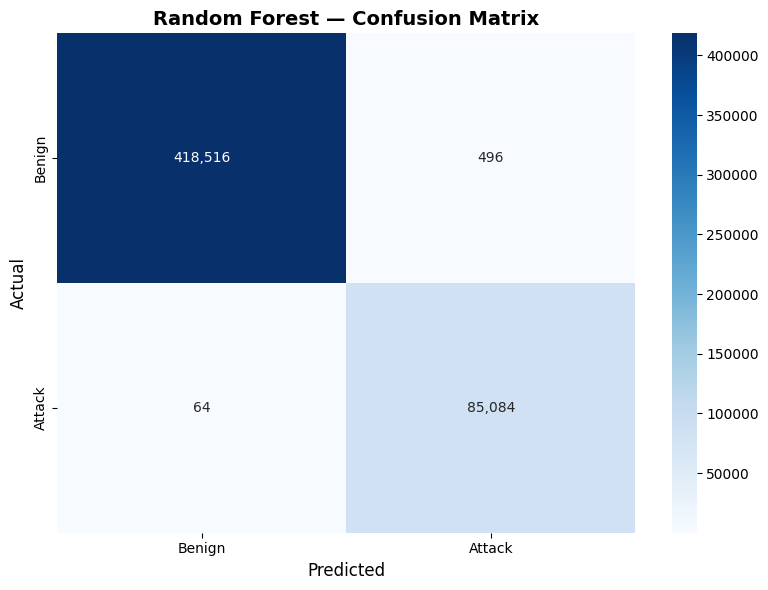


  Interpretation:
    True Negatives  (correctly benign):  418,516
    True Positives  (correctly attack):  85,084
    False Positives (false alarms):      496
    False Negatives (missed attacks):    64

    False Alarm Rate: 0.12%
    Miss Rate:        0.08%


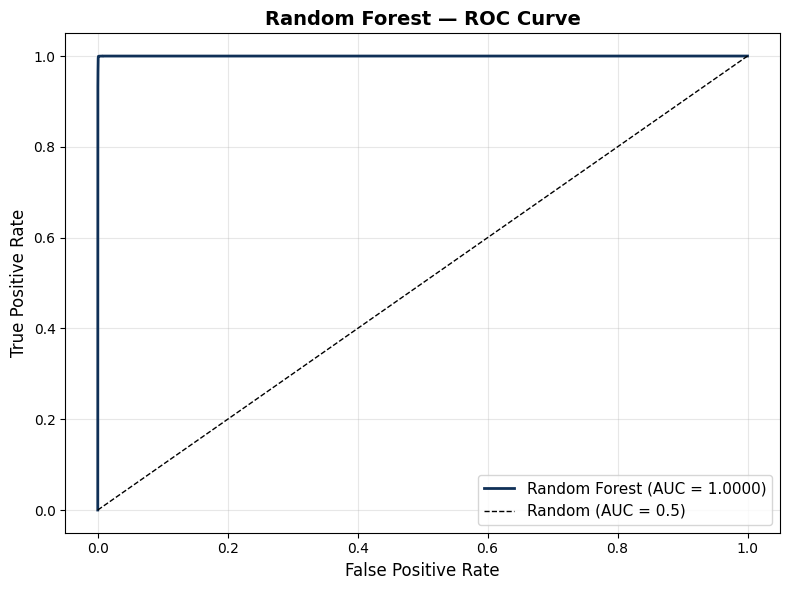

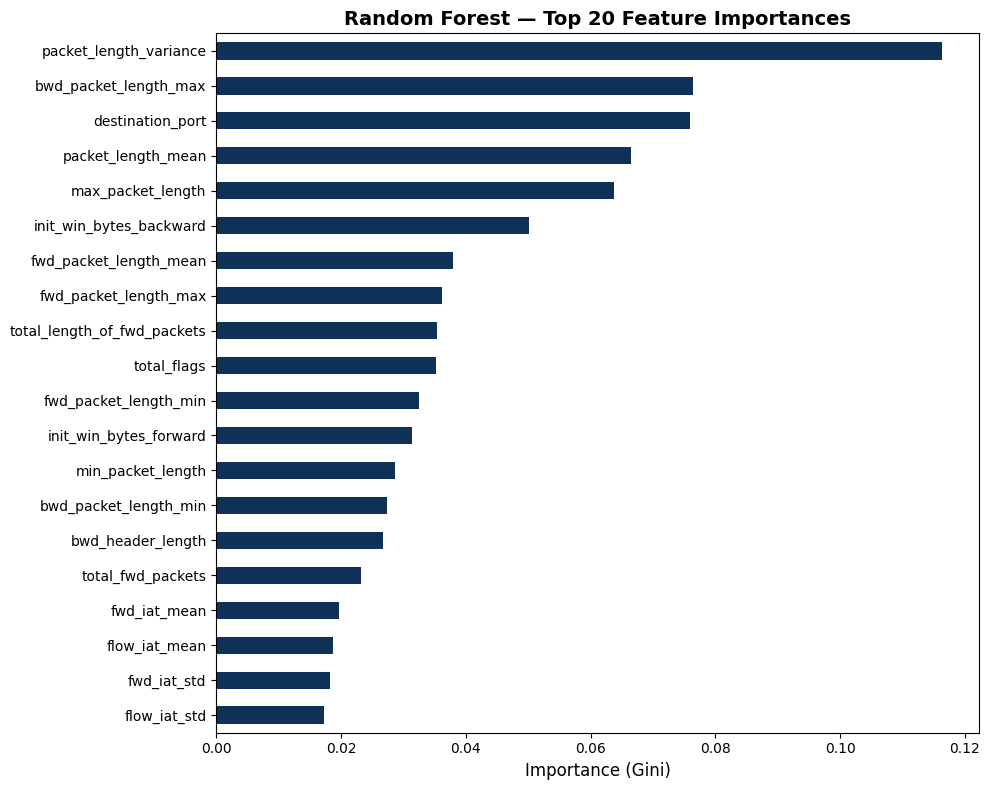


  Top 10 Most Important Features:
     1. packet_length_variance              0.1164
     2. bwd_packet_length_max               0.0764
     3. destination_port                    0.0759
     4. packet_length_mean                  0.0664
     5. max_packet_length                   0.0638
     6. init_win_bytes_backward             0.0501
     7. fwd_packet_length_mean              0.0379
     8. fwd_packet_length_max               0.0362
     9. total_length_of_fwd_packets         0.0354
    10. total_flags                         0.0352


In [7]:
# ═══════════════════════════════════════════════════
# CELL 6 — Random Forest Visualizations
# ═══════════════════════════════════════════════════
rf.plot_confusion_matrix(X_test, y_test,
    save_path="notebooks/rf_cm.png")

rf.plot_roc_curve(X_test, y_test,
    save_path="notebooks/rf_roc.png")

rf.plot_feature_importance(top_n=20,
    save_path="notebooks/rf_importance.png")

In [8]:
# ═══════════════════════════════════════════════════
# CELL 7 — Train XGBoost
# ═══════════════════════════════════════════════════
from src.models.xgboost_model import XGBoostDetector

xgb = XGBoostDetector(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.1
)

xgb.train(X_train, y_train)
xgb_results = xgb.evaluate(X_test, y_test)


TRAINING: XGBoost
  Estimators:     300
  Max depth:      10
  Learning rate:  0.1
  Subsample:      0.8
  Training samples: 3,352,090
  Features:         48
  ✅ Training complete (42.38s)

EVALUATING: XGBoost

  Metric                    Score
  ──────────────────────────────
  accuracy                 0.9991
  precision                0.9952
  recall                   0.9994
  f1                       0.9973
  roc_auc                  1.0000
  training_time             42.38s

  Classification Report:
              precision    recall  f1-score   support

      Benign     0.9999    0.9990    0.9994    419012
      Attack     0.9952    0.9994    0.9973     85148

    accuracy                         0.9991    504160
   macro avg     0.9975    0.9992    0.9984    504160
weighted avg     0.9991    0.9991    0.9991    504160



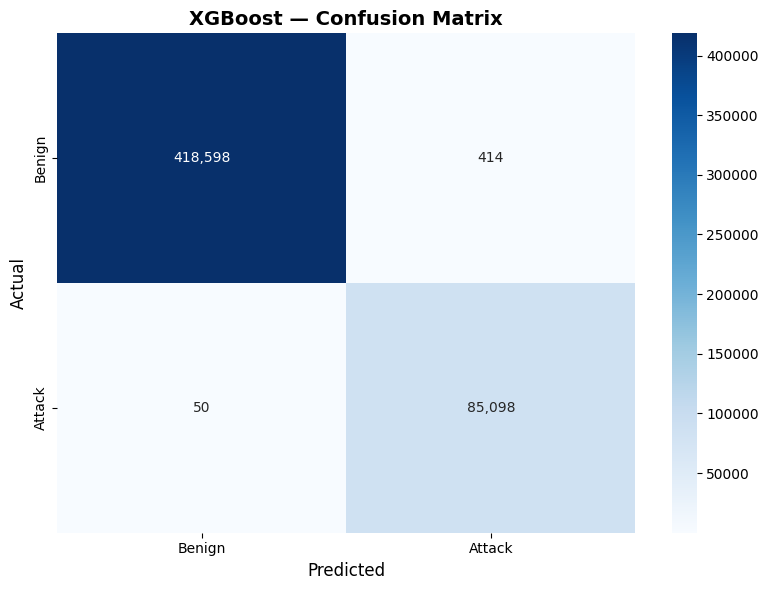


  Interpretation:
    True Negatives  (correctly benign):  418,598
    True Positives  (correctly attack):  85,098
    False Positives (false alarms):      414
    False Negatives (missed attacks):    50

    False Alarm Rate: 0.10%
    Miss Rate:        0.06%


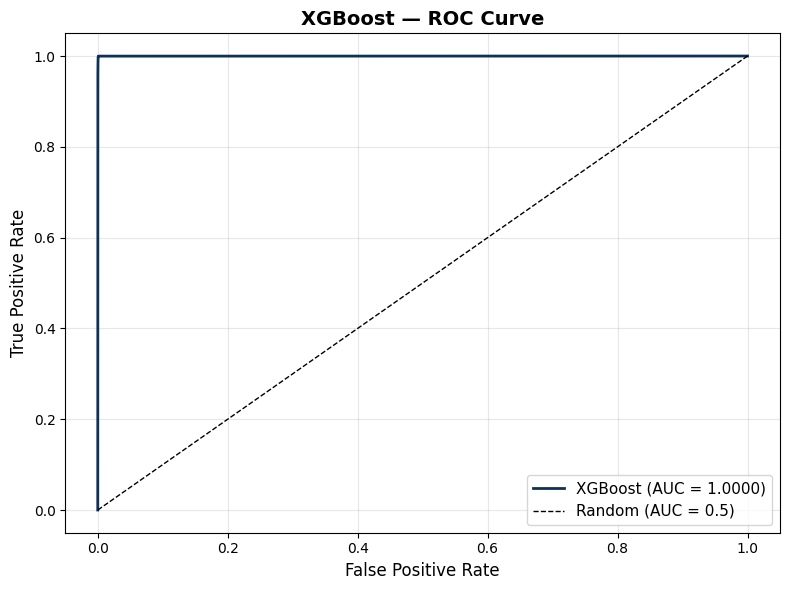

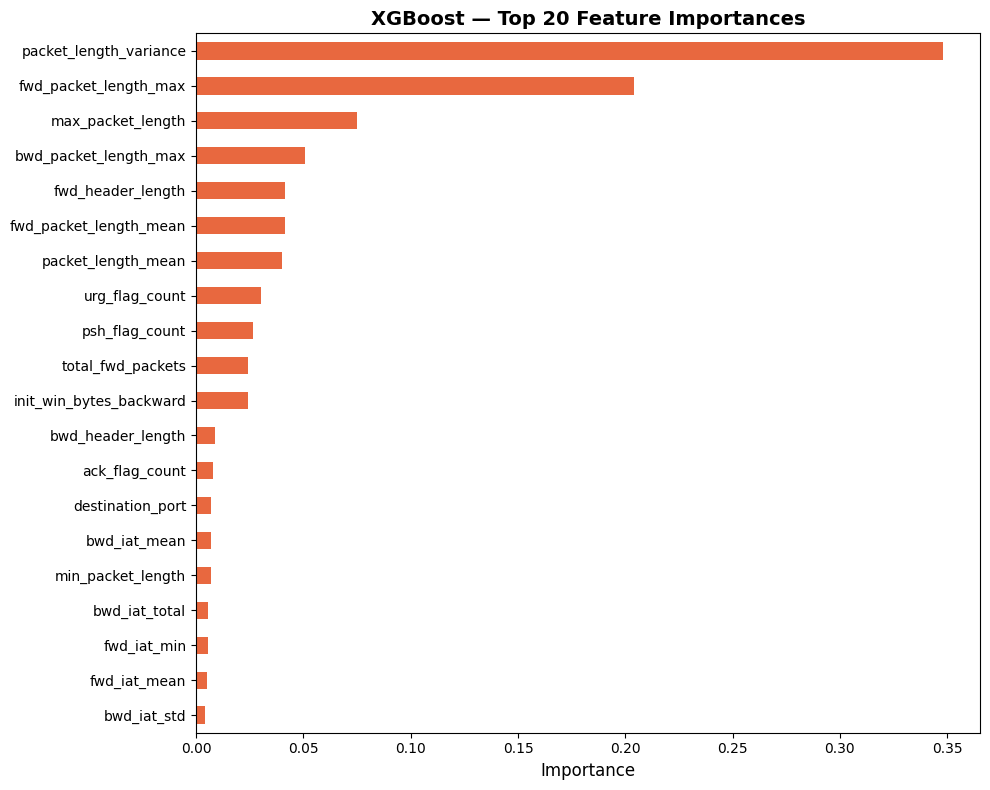

In [9]:
# ═══════════════════════════════════════════════════
# CELL 8 — XGBoost Visualizations
# ═══════════════════════════════════════════════════
xgb.plot_confusion_matrix(X_test, y_test,
    save_path="notebooks/xgb_cm.png")

xgb.plot_roc_curve(X_test, y_test,
    save_path="notebooks/xgb_roc.png")

xgb.plot_feature_importance(top_n=20,
    save_path="notebooks/xgb_importance.png")

In [10]:
# ═══════════════════════════════════════════════════
# CELL 9 — Train Autoencoder
# ═══════════════════════════════════════════════════
from src.models.autoencoder import AutoencoderDetector

ae = AutoencoderDetector(
    input_dim=X_train.shape[1],
    encoding_dim=16,
    hidden_layers=[64, 32],
    epochs=50,
    batch_size=256,
    threshold_percentile=95
)

ae.train(X_train, y_train)
ae_results = ae.evaluate(X_test, y_test)


TRAINING: Autoencoder
  Architecture:     48 → 64 → 32 → [16] → 32 → 64 → 48
  Normal samples:   1,676,045
  Epochs:           50
  Batch size:       256
  Learning rate:    0.001
Epoch 1/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.4557 - val_loss: 0.2014 - learning_rate: 0.0010
Epoch 2/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3713 - val_loss: 0.2055 - learning_rate: 0.0010
Epoch 3/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3581 - val_loss: 0.3011 - learning_rate: 0.0010
Epoch 4/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3497 - val_loss: 0.5144 - learning_rate: 0.0010
Epoch 5/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.3388 - val_loss: 0.5194 - learning_rate: 5.0000e-04
Epoch 6/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3343 - val_loss: 0.4132 - learning_rate: 5.0000e-04

  ✅ Training complete (65.35s)
  Threshold (p95): 0.335582

EVALUATING: Autoencoder

  Metric                    Score
  ───────────

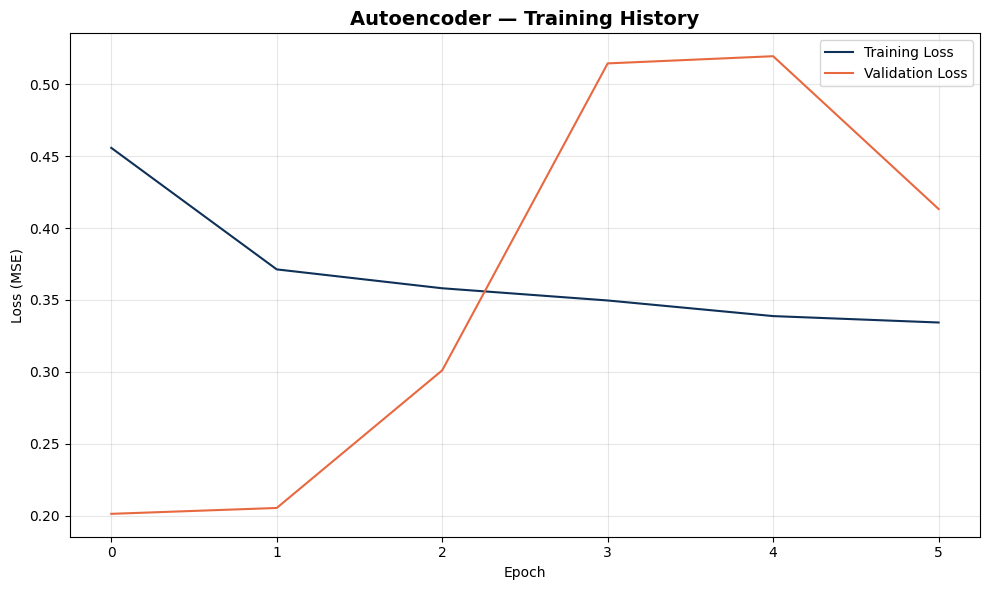

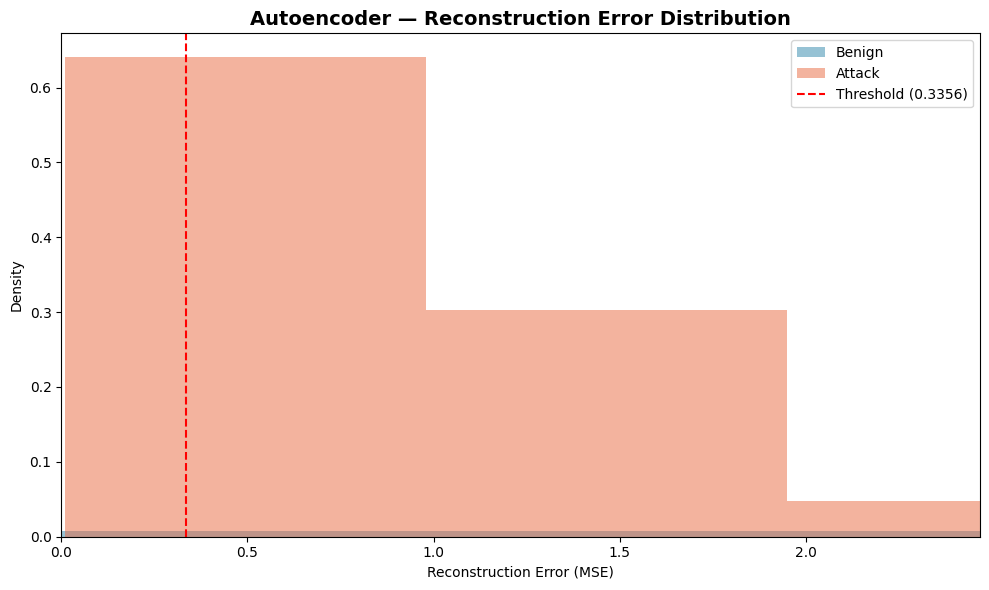

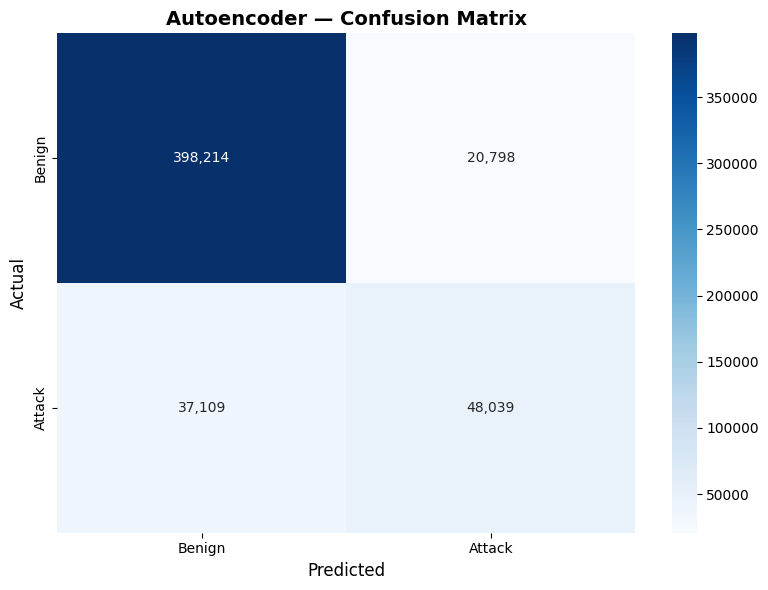


  Interpretation:
    True Negatives  (correctly benign):  398,214
    True Positives  (correctly attack):  48,039
    False Positives (false alarms):      20,798
    False Negatives (missed attacks):    37,109

    False Alarm Rate: 4.96%
    Miss Rate:        43.58%


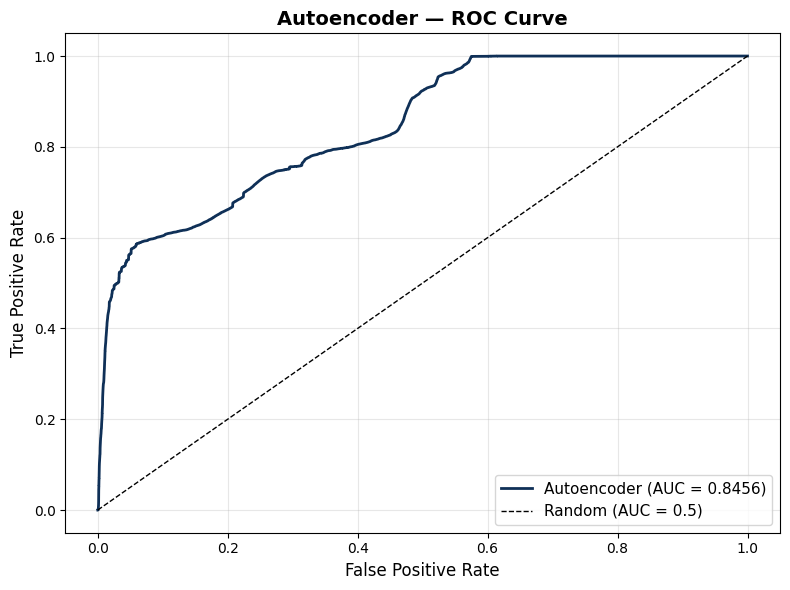

In [11]:
# ═══════════════════════════════════════════════════
# CELL 10 — Autoencoder Visualizations
# ═══════════════════════════════════════════════════
ae.plot_training_history(save_path="notebooks/ae_history.png")

ae.plot_error_distribution(X_test, y_test,
    save_path="notebooks/ae_error_dist.png")

ae.plot_confusion_matrix(X_test, y_test,
    save_path="notebooks/ae_cm.png")

ae.plot_roc_curve(X_test, y_test,
    save_path="notebooks/ae_roc.png")

In [12]:
# ═══════════════════════════════════════════════════
# CELL 11 — Model Comparison
# ═══════════════════════════════════════════════════
from src.models.comparator import ModelComparator

comparator = ModelComparator()
comparator.add_model(iso_forest)
comparator.add_model(rf)
comparator.add_model(xgb)
comparator.add_model(ae)

comparator.print_summary()


════════════════════════════════════════════════════════════════════════════════
  NetSentinel — MODEL COMPARISON SUMMARY
════════════════════════════════════════════════════════════════════════════════

  Model                           F1      AUC  Precision   Recall     Time
  ───────────────────────────────────────────────────────────────────
  XGBoost                     0.9973   1.0000     0.9952   0.9994    42.4s
  Random Forest               0.9967   1.0000     0.9942   0.9992   342.1s
  Autoencoder                 0.6239   0.8456     0.6979   0.5642    65.4s
  Isolation Forest            0.1119   0.5284     0.1450   0.0910    23.5s

  🏆 Best model (F1): XGBoost (0.9973)
════════════════════════════════════════════════════════════════════════════════


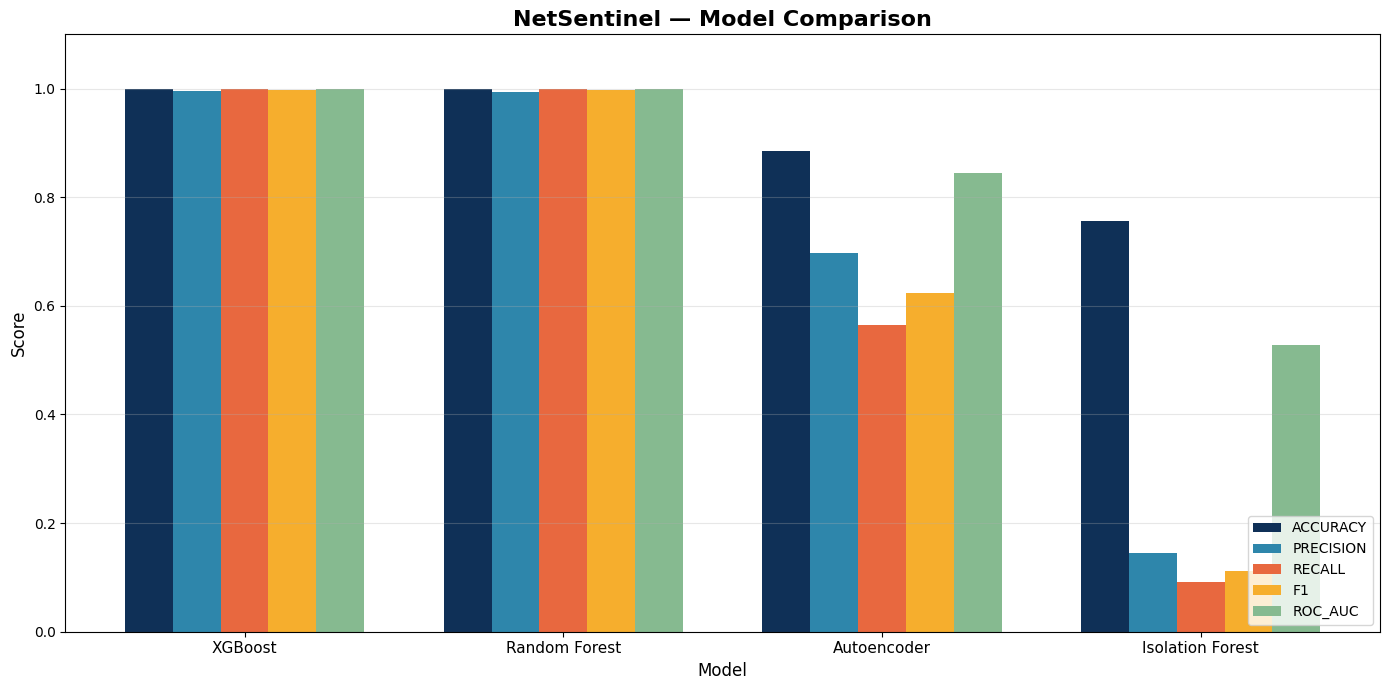

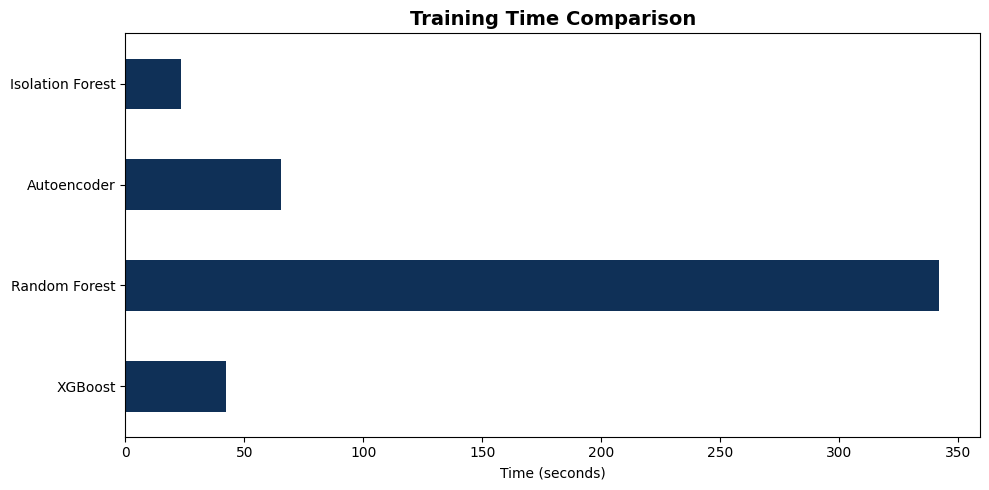

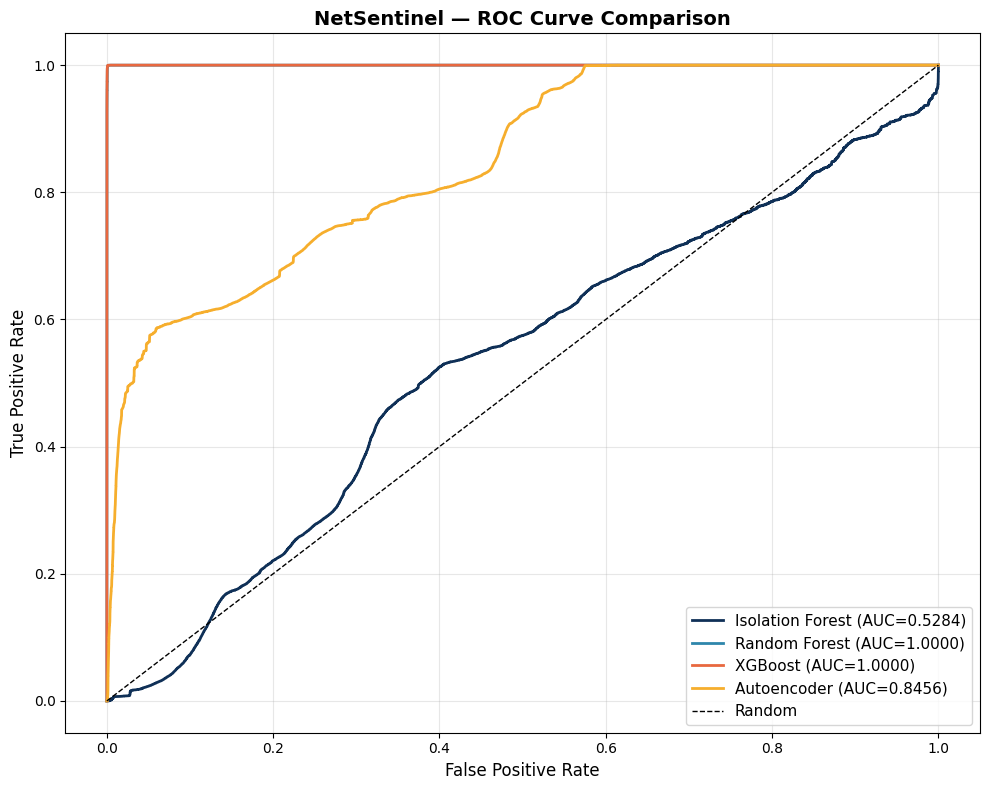

In [13]:
# ═══════════════════════════════════════════════════
# CELL 12 — Comparison Visualizations
# ═══════════════════════════════════════════════════
comparator.plot_comparison(save_path="notebooks/model_comparison.png")

comparator.plot_training_time(save_path="notebooks/training_time.png")

comparator.plot_roc_comparison(X_test, y_test,
    save_path="notebooks/roc_comparison.png")

In [14]:
# ═══════════════════════════════════════════════════
# CELL 13 — Log All Models to MLflow
# ═══════════════════════════════════════════════════
iso_forest.log_to_mlflow()
rf.log_to_mlflow()
xgb.log_to_mlflow()
ae.log_to_mlflow()

print("\n✅ All models logged to MLflow")
print("   Run 'mlflow ui' to view experiments")

  ✅ Logged to MLflow: Isolation Forest
  ✅ Logged to MLflow: Random Forest
  ✅ Logged to MLflow: XGBoost
  ✅ Logged to MLflow: Autoencoder

✅ All models logged to MLflow
   Run 'mlflow ui' to view experiments


In [15]:
# ═══════════════════════════════════════════════════
# CELL 14 — Save Best Model
# ═══════════════════════════════════════════════════
import joblib

comparison_df = comparator.get_comparison_table()
best_model_name = comparison_df['f1'].idxmax()
best_model = comparator.models[best_model_name]

print(f"🏆 Best model: {best_model_name} (F1={comparison_df.loc[best_model_name, 'f1']:.4f})")

# Save best model
if best_model_name != "Autoencoder":
    joblib.dump(best_model.model, "data/processed/best_model.pkl")
    print(f"✅ Saved to data/processed/best_model.pkl")
else:
    best_model.model.save("data/processed/best_model.h5")
    print(f"✅ Saved to data/processed/best_model.h5")

# Save comparison results
comparison_df.to_csv("data/processed/model_comparison.csv")
print(f"✅ Comparison table saved")

print(f"\n✅ Phase 3 Complete!")

🏆 Best model: XGBoost (F1=0.9973)
✅ Saved to data/processed/best_model.pkl
✅ Comparison table saved

✅ Phase 3 Complete!
